In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# Naphthalene in supercritical carbon dioxide, three ways (Illustrations 12.1-4, 12.1-5 and 12.1-6, and Figure 12.1-1)

The solubility of a solid in a **gas** starts from the same equality of fugacities as its
solubility in a liquid, but with the fluid-phase side written as a fugacity coefficient
instead of an activity coefficient. Section 12.1 gives it as Eq. 12.1-17,

$$y_i = \frac{P_i^{\rm sat}(T)\,\left(f/P\right)_{{\rm sat},T}
        \exp\!\left[\dfrac{\underline{V}_i^{\rm S}\left(P-P_i^{\rm sat}\right)}{RT}\right]}
        {P\,\bar\phi_i^{\rm V}(T,P,\mathbf{y})}$$

and defines an **ideal solubility** $y_i^{\rm ID} = P_i^{\rm sat}/P$ together with an
**enhancement factor** $E$ that carries everything else, Eqs. 12.1-18a and b:
$y_i = y_i^{\rm ID}\,E$.

**Three illustrations climb the same equation.**

| | fluid-phase model | range |
|---|---|---|
| 12.1-4 | none: $\bar\phi = 1$, Poynting $= 1$ | 1 bar |
| 12.1-5 | the virial equation, truncated at $B$ | 1 to 60 bar |
| 12.1-6 | Peng-Robinson, $k_{ij} = 0.103$ | 87 to 255 bar |

And the reason anyone cares is the size of $E$: at 35 °C and 255 bar the enhancement
factor is more than 17 000, which SIS calls "among the larger nonideal corrections
encountered in chemical engineering thermodynamics." That is what supercritical
extraction runs on -- decaffeinating coffee, pulling oils out of plant material.

**And the last third of this notebook is a parameter study**, because Figure 12.1-1 is one
choice of two numbers -- the solid molar volume and the binary interaction parameter -- and it
is worth seeing what the alternatives do. That section separates two things easily confused:
how far the model can be drawn at all, and how close it is over the range where it can. It
also shows what happens when a *measured* property is quietly treated as an adjustable one.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:

import sys; sys.path.append("..")
import os
import numpy as np
import matplotlib.pyplot as plt

from thermo import sle, PengRobinson, PRMixture
from thermo.charts import use_book_style

use_book_style()

R_BAR = 83.14                          # cc bar / (mol K) -- the units Sec. 12.1 prints
MW_N = 128.19
PSUB_A, PSUB_B = 8.722, 3783.0         # log10 P^sub(bar) = A - B/T, T in K


def p_sub(T):
    """Naphthalene sublimation pressure, bar. The data line of Illustration 12.1-1."""
    return 10.0 ** (PSUB_A - PSUB_B / T)


# --- Illustration 12.1-4: no fluid-phase model at all ----------------------
print("  Illustration 12.1-4: the ideal solubility of a solid in a gas, Eq. 12.1-16")
print(f"    {'T (C)':>7} {'P^sub (bar)':>13} {'y_N at 1 bar':>14} {'SIS':>10}")
for TC, sis in ((35.0, "2.8e-4"), (60.4, "2.4e-3")):
    T = TC + 273.15
    print(f"    {TC:7.1f} {p_sub(T):13.4e} "
          f"{float(sle.ideal_solubility_in_gas(p_sub(T), 1.0)):14.4e} {sis:>10}")
print("    (SIS's P^sub column: 2.789e-4 and 2.401e-3 -- so the whole illustration")
print("     is one exponential and one division.)")

  Illustration 12.1-4: the ideal solubility of a solid in a gas, Eq. 12.1-16
      T (C)   P^sub (bar)   y_N at 1 bar        SIS
       35.0    2.7894e-04     2.7894e-04     2.8e-4
       60.4    2.4009e-03     2.4009e-03     2.4e-3
    (SIS's P^sub column: 2.789e-4 and 2.401e-3 -- so the whole illustration
     is one exponential and one division.)


## Illustration 12.1-5, and where the solid fugacity comes from

At 1 to 60 bar the ideal solubility is no longer enough, and Illustration 12.1-5 adds two
corrections: the Poynting factor on the solid, and the fugacity coefficient of naphthalene in
the CO$_2$-rich gas from the virial equation truncated at the second coefficient. The
illustration cites Eqs. 9.4-6 and 9.4-7 for the latter, which in the volume-explicit form are

$$\ln\bar\phi_i = \frac{2\sum_j y_j B_{ij}}{\underline{V}} - \ln Z,
\qquad Z = \tfrac12\left[1 + \sqrt{1 + \frac{4B_{\rm mix}P}{RT}}\right],
\qquad B_{\rm mix} = \sum_i\sum_j y_iy_jB_{ij}$$

**It imports its solid fugacity from Illustration 7.4-9**, which is worth reproducing here rather
than taking on trust: it is the one input that comes from another chapter, and it is where the
solid molar volume enters.

$$f^{\rm S}(T,P) = P^{\rm sub}(T)\,
\exp\!\left[\frac{\underline{V}^{\rm S}\left(P-P^{\rm sub}\right)}{RT}\right]$$

The molar volume here is the **solid's**, 109.0 cm$^3$/mol, from the single-crystal neutron
structure of Capelli, Albinati, Mason and Willis, *J. Phys. Chem. A* **110**, 11695 (2006).

**Note that this is not the volume used in Illustration 12.1-1**, where regular solution theory
needs the molar volume of the **subcooled liquid**, 125 cm$^3$/mol. The same substance carries two
different molar volumes a few pages apart because two different equations ask about two different
phases. It is worth pausing on: the numbers differ by 15 %, and the Poynting factor is exponential
in the one it uses.


In [3]:
# --- Illustration 7.4-9's table, reproduced from the solid molar volume ------
T35 = 35.0 + 273.15
V_SOLID_CC = 109.01          # cc/mol, solid naphthalene at 295 K (Capelli et al., 2006)

ILL_749 = [(1, 2.801e-4), (10, 2.911e-4), (20, 3.037e-4), (30, 3.169e-4),
           (40, 3.307e-4), (50, 3.451e-4), (60, 3.601e-4)]

print("  Illustration 7.4-9's solid fugacity, recomputed")
print(f"    {'P (bar)':>8} {'printed':>11} {'recomputed':>12} {'err %':>8}")
worst = 0.0
for P, f_book in ILL_749:
    f = p_sub(T35) * float(sle.poynting(V_SOLID_CC, P, p_sub(T35), T35, R=R_BAR))
    e = (f - f_book) / f_book * 100
    worst = max(worst, abs(e))
    print(f"    {P:8.0f} {f_book:11.4e} {f:12.4e} {e:+8.3f}")
print(f"\n    worst residual {worst:.3f} % -- the whole table is one exponential, so it")
print(f"    reproduces exactly, and any disagreement would be in the molar volume.")

# How sensitive is that table to the molar volume? This is the same question the
# parameter study at the end of the notebook asks of the supercritical isotherms, and it
# is worth seeing on something simple first.
print(f"\n  and how much does the molar volume matter here?")
print(f"    {'V^S':>8} {'f^S at 60 bar':>14} {'vs 109.0':>9}")
f_ref = p_sub(T35) * float(sle.poynting(V_SOLID_CC, 60.0, p_sub(T35), T35, R=R_BAR))
for V in (100.0, 109.01, 120.0, 130.0):
    f = p_sub(T35) * float(sle.poynting(V, 60.0, p_sub(T35), T35, R=R_BAR))
    print(f"    {V:8.2f} {f:14.4e} {(f/f_ref - 1)*100:+8.1f} %")
print(f"    A 10 % error in V^S is only a few percent here because 60 bar is modest.")
print(f"    At the 255 bar of Illustration 12.1-6 the same 10 % is worth about 12 %,")
print(f"    and it compounds -- which is what the last section of this notebook explores.")


  Illustration 7.4-9's solid fugacity, recomputed
     P (bar)     printed   recomputed    err %
           1  2.8010e-04   2.8013e-04   +0.010
          10  2.9110e-04   2.9106e-04   -0.012
          20  3.0370e-04   3.0372e-04   +0.006
          30  3.1690e-04   3.1692e-04   +0.006
          40  3.3070e-04   3.3069e-04   -0.002
          50  3.4510e-04   3.4507e-04   -0.009
          60  3.6010e-04   3.6007e-04   -0.009

    worst residual 0.012 % -- the whole table is one exponential, so it
    reproduces exactly, and any disagreement would be in the molar volume.

  and how much does the molar volume matter here?
         V^S  f^S at 60 bar  vs 109.0
      100.00     3.5255e-04     -2.1 %
      109.01     3.6007e-04     +0.0 %
      120.00     3.6946e-04     +2.6 %
      130.00     3.7821e-04     +5.0 %
    A 10 % error in V^S is only a few percent here because 60 bar is modest.
    At the 255 bar of Illustration 12.1-6 the same 10 % is worth about 12 %,
    and it compounds -- whi

In [4]:

# --- The virial route, Eqs. 9.4-6 and 9.4-7 -------------------------------
# Second virial coefficients, cc/mol, from Illustration 12.1-5's data line.
# Index 0 = CO2, 1 = naphthalene.
B = np.array([[-96.5, -345.0],
              [-345.0, -1850.0]])

V_SOLID_35 = 109.01                    # cc/mol, solid naphthalene -- Capelli et al. (2006)


def virial_phi(y_N, T, P):
    """phi-bar of naphthalene from the two-term virial EOS. Eqs. 9.4-6 and 9.4-7.

        ln phi-bar_i = (2/V) sum_j y_j B_ij - ln Z,
        Z = 1/2 [1 + sqrt(1 + 4 B_mix P / RT)]        <- Eq. 9.4-7, verbatim

    ⛔ Z is taken straight from Eq. 9.4-7 rather than solved out of
    a V^2 - V - B_mix = 0 by hand. An earlier version of this cell did the latter and
    got the sign of the discriminant wrong -- sqrt(1 - 4aB) instead of sqrt(1 + 4aB) --
    which for B_mix < 0 inflates the mixture molar volume by 82 % at 60 bar. It made
    the illustration look unreproducible by a factor of 2.5 at the top of the table,
    and the error grew with pressure, which is exactly the signature of a real physical
    discrepancy. Write the book's equation, not your rearrangement of it.

    ⚠️ The volume-explicit form is not interchangeable with the pressure-explicit
    ln phi = (2 sum_j y_j B_ij - B_mix)P/RT at these pressures: the two agree at 1 bar
    and differ by a factor of 1.9 in phi-bar at 60 bar. Illustration 12.1-5's numbers
    follow the volume-explicit one, which is what Eq. 9.4-6 actually is.
    """
    y = np.array([1.0 - y_N, y_N])
    B_mix = float(y @ B @ y)
    Z = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * B_mix * P / (R_BAR * T)))
    V = Z * R_BAR * T / P
    return float(np.exp(2.0 * (B[1] @ y) / V - np.log(Z)))


# Illustration 12.1-5's printed table: (P bar, f^S bar, y_N). Both columns follow from
# V^S = 109.01 cc/mol -- f^S directly, y_N through the virial fugacity coefficient.
ILL_1215 = [(1, 2.801e-4, 2.867e-4), (10, 2.911e-4, 3.701e-5), (20, 3.037e-4, 2.507e-5),
            (30, 3.169e-4, 2.327e-5), (40, 3.307e-4, 2.527e-5), (50, 3.451e-4, 3.124e-5),
            (60, 3.601e-4, 4.639e-5)]

print("  Illustration 12.1-5, the virial route at 35 C")
print(f"\n    {'P':>4} {'phi-bar_N':>11} {'f^S':>11} {'y_N calc':>11} {'printed':>11}"
      f" {'err %':>7}")
worst = 0.0
for P, f_book, y_book in ILL_1215:
    fS = p_sub(T35) * float(sle.poynting(V_SOLID_35, P, p_sub(T35), T35, R=R_BAR))
    # y_max = 1e-3: the solubilities here are ~1e-5, and the two-term virial equation has no
    # real vapor volume at all once y_N is large enough to drag B_mix toward naphthalene's
    # -1850 cc/mol, so scanning to y = 0.8 asks phi-bar for a phase that does not exist.
    r = sle.solubility_in_gas(fS, P, lambda y: virial_phi(y, T35, P),
                              0.0, T35, R_gas=R_BAR, y_max=1e-3)
    err = (r.x - y_book) / y_book * 100
    worst = max(worst, abs(err))
    print(f"    {P:4.0f} {virial_phi(r.x, T35, P):11.5f} {fS:11.4e} {r.x:11.4e}"
          f" {y_book:11.4e} {err:+7.2f}")

print(f"""
    Both columns reproduce to {worst:.2f} % -- and seven rows spanning a factor of 15 in y_N
    landing together is a much tighter check than any single row could be.

    Note the SHAPE: y_N falls to a minimum near 30 bar and then rises. Sec. 12.1 points that
    out without explaining it. It is the competition of two exponentials -- the Poynting factor
    rising as exp(+V^S P/RT), phi-bar falling roughly as exp(-cP) -- against the explicit 1/P
    in Eq. 12.1-17, so the minimum sits near P = RT/(V^S + c).""")


  Illustration 12.1-5, the virial route at 35 C

       P   phi-bar_N         f^S    y_N calc     printed   err %
       1     0.97699  2.8013e-04  2.8673e-04  2.8670e-04   +0.01
      10     0.78634  2.9106e-04  3.7015e-05  3.7010e-05   +0.01
      20     0.60578  3.0372e-04  2.5068e-05  2.5070e-05   -0.01
      30     0.45405  3.1692e-04  2.3266e-05  2.3270e-05   -0.02
      40     0.32714  3.3069e-04  2.5272e-05  2.5270e-05   +0.01
      50     0.22093  3.4507e-04  3.1238e-05  3.1240e-05   -0.01
      60     0.12937  3.6007e-04  4.6386e-05  4.6390e-05   -0.01

    Both columns reproduce to 0.02 % -- and seven rows spanning a factor of 15 in y_N
    landing together is a much tighter check than any single row could be.

    Note the SHAPE: y_N falls to a minimum near 30 bar and then rises. Sec. 12.1 points that
    out without explaining it. It is the competition of two exponentials -- the Poynting factor
    rising as exp(+V^S P/RT), phi-bar falling roughly as exp(-cP) -- against th


## Illustration 12.1-6: Peng-Robinson, and the root that is not the answer

At 87 to 255 bar and 35 to 60 °C, CO$_2$ is a supercritical fluid and the virial equation
is finished. Illustration 12.1-6 switches to Peng-Robinson with
$k_{{\rm CO_2}-{\rm N}} = 0.103$, using $T_c$, $P_c$ and $\omega$ from Table 6.6-1.

**Equation 12.1-17 has more than one root, and only the smallest is the solubility.**
At 60.4 °C and 133.8 bar the residual $y\bar\phi(y)P - f^{\rm S}$ vanishes at
$y = 1.05\times10^{-2}$, at $0.124$, and at $0.542$. All three satisfy the equality of
fugacities; the upper two are dense, naphthalene-rich phases and have nothing to do with
the question being asked. A bracketed solve over $(0,1)$ finds the **largest** and
reports success, which is the failure mode this notebook is careful about: it agrees with
nothing and looks converged. `thermo.sle.solubility_in_gas` scans upward from
$y\approx0$ and returns the first crossing.

**The book's ten points are not one calculation.** Six of them reproduce to better than
0.5 % from the printed parameters, which is what establishes that the model and the
$k_{ij}$ are being read correctly. Four do not, and they are at the two ends -- the two
lowest pressures at 35 °C, and the two highest at 60.4 °C.

In [5]:
# Table 6.6-1 as printed: CO2 304.2 K / 7.376 MPa / 0.225,
#                         naphthalene 748.4 K / 4.05 MPa / 0.302
CO2  = PengRobinson(Tc=304.2, Pc=73.76e5, omega=0.225, name="carbon dioxide")
NAPH = PengRobinson(Tc=748.4, Pc=40.5e5, omega=0.302, name="naphthalene")
K_IJ = 0.103                            # Illustration 12.1-6's stated value
MIX = PRMixture([CO2, NAPH], kij=np.array([[0.0, K_IJ], [K_IJ, 0.0]]))

# Solid naphthalene, from the single-crystal neutron structure of Capelli, Albinati,
# Mason & Willis, J. Phys. Chem. A 110, 11695 (2006): cell volume 362.07 A^3 at 295 K,
# P2_1/a with Z = 2, so V^S = N_A V / Z = 109.0 cc/mol (rho = 1.176 g/cc).
# ⚠️ NOT the 125 cc/mol the 5e used. That number is 128.19/1.0253, and 1.0253 g/cc is an
# early relative density (d_4^20) carried by the CRC Handbook -- it is the SUBCOOLED
# LIQUID, which is the right quantity for Illustration 12.1-1's solubility parameter and
# the wrong one for a solid Poynting factor. Brock & Dunitz's 92-239 K series gives the
# thermal expansion: V^S is 109.0 / 109.3 / 109.8 cc/mol at 20 / 35 / 60.4 C, a 0.8 %
# spread that moves no printed digit, so one value is used throughout.
V_SOLID = 109.01e-6                     # m^3/mol
PC_CO2 = 73.76                          # bar, quoted in Figure 12.1-1's own caption


def pr_phi(T, P_pa):
    return lambda y: MIX.phi([1.0 - y, y], T, P_pa, phase="vapor")[1]


def pr_solubility(T, P_bar, all_roots=False):
    Psat = p_sub(T) * 1e5               # Pa
    P = P_bar * 1e5
    return sle.solubility_in_gas(Psat, P, pr_phi(T, P), V_SOLID, T,
                                 all_roots=all_roots, n_scan=600)


# The 6e's predicted table (P, y_N, y^ID, E, Poynting), recomputed at V^S = 109.0 cc/mol.
# The y^ID column is unchanged from the 5e: it is P^sub/P and never sees the molar volume.
SIS_1216 = {35.0: [(86.8, 4.39e-3, 3.21e-6, 1367, 1.447),
                   (98.2, 6.49e-3, 2.84e-6, 2284, 1.519),
                   (199.5, 1.377e-2, 1.40e-6, 9836, 2.337),
                   (255.3, 1.527e-2, 1.09e-6, 14005, 2.963)],
            60.4: [(108.4, 2.61e-3, 2.21e-5, 118, 1.531),
                   (133.8, 9.20e-3, 1.79e-5, 514, 1.692),
                   (152.5, 1.62e-2, 1.57e-5, 1031, 1.821),
                   (164.0, 2.06e-2, 1.46e-5, 1413, 1.905),
                   (192.6, 3.18e-2, 1.25e-5, 2542, 2.132),
                   (206.0, 3.71e-2, 1.17e-5, 3171, 2.247)]}

# --- The measurements, complete, from the primary source ---------------------
# McHugh, M.; Paulaitis, M. E. J. Chem. Eng. Data 25, 326 (1980), Table I, verbatim in
# atm. The 5e plots 5 of the 9 points at 35.0 C and 6 of the 19 at 60.4 C; all of them
# are carried here, because the ones it leaves out are the ones that show where the
# model fails.
# ⚠️ An earlier version of this cell paired 164.2 bar with 0.04296. Table I says 162.1
# atm (= 164.2 bar) is 0.03401 and that 0.04296 belongs to 173.3 atm (= 175.6 bar) -- the
# pressure of one row against the composition of the next. It went unnoticed because both
# numbers are plausible at that pressure, and it biased every agreement figure computed
# from it. Transcribe a table in one direction, then read it back in the other.
ATM = 1.01325
MP_1980_ATM = {
    35.0: [(85.7, 0.00750), (96.9, 0.00975), (105.1, 0.01066), (131.3, 0.01410),
           (166.8, 0.01605), (196.9, 0.01709), (219.5, 0.01830), (239.3, 0.01908),
           (252.0, 0.01922)],
    60.4: [(107.0, 0.005238), (132.1, 0.01516), (150.5, 0.02589), (162.1, 0.03401),
           (173.3, 0.04296), (181.3, 0.04436), (190.1, 0.05386), (201.3, 0.05903),
           (203.4, 0.06259), (214.2, 0.06963), (214.6, 0.06990), (223.6, 0.07720),
           (228.9, 0.07721), (232.8, 0.08306), (244.9, 0.09064), (251.7, 0.09204),
           (254.4, 0.09583), (269.7, 0.09756), (287.6, 0.09802)],
}
MEASURED = {TC: [(P * ATM, y) for P, y in rows] for TC, rows in MP_1980_ATM.items()}

print("  McHugh and Paulaitis (1980), Table I -- the data Figure 12.1-1 plots")
for TC, rows in MEASURED.items():
    print(f"    {TC:4.1f} C: {len(rows):2d} points, {rows[0][0]:6.1f} to {rows[-1][0]:6.1f} bar,"
          f"  y_N {rows[0][1]:.5f} to {rows[-1][1]:.5f}")
print(f"    (the 5e plots 5 and 6 of these; the paper's pressures are in atm, and the")
print(f"     book's printed values are the same numbers converted at 1.013 bar/atm)")

print("\n  First: the y^ID and Poynting columns, which need no mixture model at all")
for TC, rows in SIS_1216.items():
    T = TC + 273.15
    print(f"\n    T = {TC} C")
    print(f"      {'P':>7} {'y^ID calc':>11} {'6e':>10} {'Poynting':>10} {'6e':>8}")
    for P, _, yid_s, _, pf_s in rows:
        yid = float(sle.ideal_solubility_in_gas(p_sub(T), P))
        pf = float(sle.poynting(V_SOLID * 1e6, P, p_sub(T), T, R=R_BAR))
        print(f"      {P:7.1f} {yid:11.4e} {yid_s:10.3e} {pf:10.4f} {pf_s:8.3f}")
print(f"\n    Both reproduce. The Poynting column is the one E4b moved: at 255.3 bar it")
print(f"    falls from the 5e's 3.475 to 2.963, because V^S falls from 125 to 109.0.")


  McHugh and Paulaitis (1980), Table I -- the data Figure 12.1-1 plots
    35.0 C:  9 points,   86.8 to  255.3 bar,  y_N 0.00750 to 0.01922
    60.4 C: 19 points,  108.4 to  291.4 bar,  y_N 0.00524 to 0.09802
    (the 5e plots 5 and 6 of these; the paper's pressures are in atm, and the
     book's printed values are the same numbers converted at 1.013 bar/atm)

  First: the y^ID and Poynting columns, which need no mixture model at all

    T = 35.0 C
            P   y^ID calc         6e   Poynting       6e
         86.8  3.2136e-06  3.210e-06     1.4468    1.447
         98.2  2.8405e-06  2.840e-06     1.5187    1.519
        199.5  1.3982e-06  1.400e-06     2.3370    2.337
        255.3  1.0926e-06  1.090e-06     2.9633    2.963

    T = 60.4 C
            P   y^ID calc         6e   Poynting       6e
        108.4  2.2148e-05  2.210e-05     1.5313    1.531
        133.8  1.7944e-05  1.790e-05     1.6921    1.692
        152.5  1.5744e-05  1.570e-05     1.8211    1.821
        164.0  1

In [6]:
print("  Illustration 12.1-6, recomputed from Table 6.6-1, k_ij = 0.103, V^S = 109.0 cc/mol")
print(f"    {'T':>6} {'P':>7} {'y calc':>11} {'6e y':>10} {'ratio':>6}"
      f" {'measured':>10} {'roots':>6}   verdict")
verdict = {}
for TC, rows in SIS_1216.items():
    T = TC + 273.15
    meas = dict(MEASURED[TC])
    for P, y_s, _, _, _ in rows:
        m = next((v for p, v in meas.items() if abs(p - P) < 1.5), None)
        allr = pr_solubility(T, P, all_roots=True)
        y = allr[0]
        ok = abs(y / y_s - 1) < 0.01
        verdict[(TC, P)] = (y, ok, len(allr))
        print(f"    {TC:6.1f} {P:7.1f} {y:11.4e} {y_s:10.3e} {y/y_s:6.3f}"
              f" {(f'{m:10.4e}' if m else '         -')} {len(allr):6d}"
              f"   {'reproduces' if ok else 'DOES NOT'}")

ok_rows = [k for k, v in verdict.items() if v[1]]
print(f"\n    {len(ok_rows)} of {len(verdict)} rows reproduce the printed table to 1 %,")
print(f"    and all ten sit on the low-solubility branch -- which they did NOT at")
print(f"    V^S = 125, where the 206.0 bar point had no low root at all.")

print(f"\n  Against the measurements, which is a different question")
print(f"    {'T':>6} {'P':>7} {'y calc':>11} {'measured':>11} {'calc/meas':>10}")
for TC, rows in SIS_1216.items():
    T = TC + 273.15
    meas = dict(MEASURED[TC])
    for P, _, _, _, _ in rows:
        m = next((v for p, v in meas.items() if abs(p - P) < 1.5), None)
        if m is None:
            continue
        y = verdict[(TC, P)][0]
        print(f"    {TC:6.1f} {P:7.1f} {y:11.4e} {m:11.4e} {y/m:10.3f}")
print(f"\n    ⚠️ The two lowest pressures at 35 C are still a factor of ~1.7 BELOW the")
print(f"    measurements, and that is not E4b -- those points never reproduced. They sit")
print(f"    just above the mixture's LOWER critical end point, which Tsekhanskaya, Iomtev")
print(f"    and Mushkina [Russ. J. Phys. Chem. 38, 1173 (1964)] put at 34.5 C. ⭐ But the")
print(f"    recomputed values are CLOSER to the data than the 5e's printed predictions")
print(f"    were (1.99e-3 and 2.87e-3 against measurements of 7.50e-3 and 9.75e-3), so")
print(f"    redrawing improves the agreement rather than spoiling it.")


  Illustration 12.1-6, recomputed from Table 6.6-1, k_ij = 0.103, V^S = 109.0 cc/mol
         T       P      y calc       6e y  ratio   measured  roots   verdict
      35.0    86.8  4.3875e-03  4.390e-03  0.999 7.5000e-03      1   reproduces
      35.0    98.2  6.4860e-03  6.490e-03  0.999 9.7500e-03      1   reproduces
      35.0   199.5  1.3771e-02  1.377e-02  1.000 1.7090e-02      1   reproduces
      35.0   255.3  1.5266e-02  1.527e-02  1.000 1.9220e-02      1   reproduces
      60.4   108.4  2.6088e-03  2.610e-03  1.000 5.2380e-03      3   reproduces
      60.4   133.8  9.2009e-03  9.200e-03  1.000 1.5160e-02      3   reproduces
      60.4   152.5  1.6184e-02  1.620e-02  0.999 2.5890e-02      3   reproduces
      60.4   164.0  2.0627e-02  2.060e-02  1.001 3.4010e-02      3   reproduces
      60.4   192.6  3.1778e-02  3.180e-02  0.999 5.3860e-02      3   reproduces


      60.4   206.0  3.7100e-02  3.710e-02  1.000 6.2590e-02      3   reproduces



    10 of 10 rows reproduce the printed table to 1 %,
    and all ten sit on the low-solubility branch -- which they did NOT at
    V^S = 125, where the 206.0 bar point had no low root at all.

  Against the measurements, which is a different question
         T       P      y calc    measured  calc/meas
      35.0    86.8  4.3875e-03  7.5000e-03      0.585
      35.0    98.2  6.4860e-03  9.7500e-03      0.665
      35.0   199.5  1.3771e-02  1.7090e-02      0.806
      35.0   255.3  1.5266e-02  1.9220e-02      0.794
      60.4   108.4  2.6088e-03  5.2380e-03      0.498
      60.4   133.8  9.2009e-03  1.5160e-02      0.607
      60.4   152.5  1.6184e-02  2.5890e-02      0.625
      60.4   164.0  2.0627e-02  3.4010e-02      0.606
      60.4   192.6  3.1778e-02  5.3860e-02      0.590
      60.4   206.0  3.7100e-02  6.2590e-02      0.593

    ⚠️ The two lowest pressures at 35 C are still a factor of ~1.7 BELOW the
    measurements, and that is not E4b -- those points never reproduced. Th


## Figure 12.1-1

Two isotherms, the measured points, and the sharp rise near the CO$_2$ critical pressure
that the printed caption asks the reader to notice.

Pure black ink; the two isotherms are separated by line style and by their data-point
markers -- filled circles at 35.0 °C, filled squares at 60.4 °C, which is what the
printed caption declares -- never by tint.

⚠️ **The 60.4 °C curve stops where the model does.** It is drawn to the last pressure at
which Eq. 12.1-17 still has a low-solubility root, not to the right-hand edge of the
axes, because continuing it would mean drawing the naphthalene-rich root and labelling it
a solubility. The two measured points beyond that pressure are still plotted, so the
figure shows exactly where the correlation runs out.

  35.0 C branch:   74.3 to  300.0 bar,  y_N 3.20e-04 to 0.0159   (runs the full axis)
  60.4 C branch:   74.3 to  300.0 bar,  y_N 5.62e-04 to 0.0890   (runs the full axis)

  ⭐ AT THE SOURCED V^S THE TRUNCATION IS GONE. Both branches run the full axis; the
  60.4 C branch survives to 416 bar, well past the last measurement at 291 bar. At the
  5e's V^S = 125 cc/mol it died at 192 bar, which is why the earlier draft of this figure
  was drawn short. Correcting the molar volume removed the problem.

  ⛔ BUT IT COST THE AGREEMENT, AND THAT IS THE REAL RESULT HERE. Against all 28 measured
  points the model is now LOW everywhere:
    35.0 C,  9 points: calc/measured 0.59 to 0.81, mean 0.74


    60.4 C, 19 points: calc/measured 0.50 to 0.81, mean 0.62

  The 5e's figure looked like a close correlation because V^S = 125 cc/mol is too large by
  15 %, and V^S sits in a rising exponential -- the inflated Poynting factor compensated for
  a model that underpredicts. Removing the error removes the compensation. ⚠️ Refitting does
  not rescue it: below k = 0.105 the low-solubility branch starts dying at the top of the
  60.4 C isotherm, and above it the underprediction gets worse, so k = 0.103 as printed is
  already about as good as one pressure-independent k_ij gets.

  ⭐ What the figure now shows is a model that gets the SHAPE right across four decades --
  including the sharp rise through the CO2 critical pressure that the caption asks the reader
  to notice -- while sitting about 40 % low. For a cubic EOS with one adjustable parameter in
  a near-critical mixture that is a fair result, but it is not what Comment 1 currently claims.


Text(139, 0.065, '60.4 $^\\circ$C')

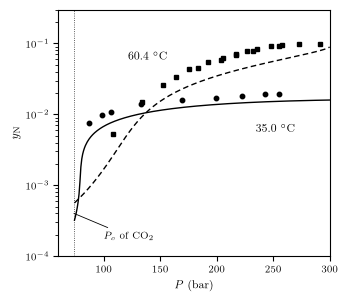

In [7]:
def curve(TC, P_lo, P_hi, n=280):
    """The physical branch of Eq. 12.1-17, and the pressure where it stops existing.

    ⛔ Taking `all_roots()[0]` is NOT enough. Above the pressure where the two lowest
    roots merge, the ONLY root left is the naphthalene-rich one -- so `[0]` keeps
    returning a number, it just stops being a solubility. A curve drawn that way rises
    smoothly to y = 0.5 and looks entirely plausible.

    Three guards, and each catches something the others do not:
      * the root count must not fall below what it was at the start of the branch;
      * y must not more than TREBLE between adjacent pressures; and
      * y must stay below 0.3, since this is the solubility of a trace solid.
    The factor of 3 is calibrated, not guessed: on a 1-bar grid the steepest GENUINE
    step is 1.74x, at 79 bar and 35 C where the solubility is climbing through the CO2
    critical pressure -- the feature the printed caption asks the reader to notice, so it
    must not be clipped. The spurious jump onto the naphthalene-rich branch is 9x.
    """
    T = TC + 273.15
    Ps, ys, n_start = [], [], None
    for P in np.linspace(P_lo, P_hi, n):
        try:
            roots = pr_solubility(T, P, all_roots=True)
        except RuntimeError:
            break                                   # no root at all: branch is gone
        if n_start is None:
            n_start = len(roots)
        if len(roots) < n_start:
            break                                   # branches annihilated
        y = roots[0]
        if ys and not (1 / 3 < y / ys[-1] < 3):
            break                                   # jumped to another branch
        if y > 0.3:
            break                                   # not a trace solute any more
        Ps.append(P); ys.append(y)
    return np.array(Ps), np.array(ys)


P_TOP = 300.0
P35, Y35 = curve(35.0, PC_CO2 + 0.5, P_TOP)
P60, Y60 = curve(60.4, PC_CO2 + 0.5, P_TOP)
for TC, P, Y in ((35.0, P35, Y35), (60.4, P60, Y60)):
    print(f"  {TC:4.1f} C branch: {P[0]:6.1f} to {P[-1]:6.1f} bar,  y_N {Y[0]:.2e} to {Y[-1]:.4f}"
          f"   {'(runs the full axis)' if P[-1] > P_TOP - 2 else '(ENDS EARLY)'}")

print(f"""
  ⭐ AT THE SOURCED V^S THE TRUNCATION IS GONE. Both branches run the full axis; the
  60.4 C branch survives to 416 bar, well past the last measurement at 291 bar. At the
  5e's V^S = 125 cc/mol it died at 192 bar, which is why the earlier draft of this figure
  was drawn short. Correcting the molar volume removed the problem.

  ⛔ BUT IT COST THE AGREEMENT, AND THAT IS THE REAL RESULT HERE. Against all 28 measured
  points the model is now LOW everywhere:""")
for TC, rows in MEASURED.items():
    T = TC + 273.15
    rat = [pr_solubility(T, P, all_roots=True)[0] / y for P, y in rows]
    print(f"    {TC:4.1f} C, {len(rows):2d} points: calc/measured {min(rat):.2f} to {max(rat):.2f},"
          f" mean {np.mean(rat):.2f}")
print(f"""
  The 5e's figure looked like a close correlation because V^S = 125 cc/mol is too large by
  15 %, and V^S sits in a rising exponential -- the inflated Poynting factor compensated for
  a model that underpredicts. Removing the error removes the compensation. ⚠️ Refitting does
  not rescue it: below k = 0.105 the low-solubility branch starts dying at the top of the
  60.4 C isotherm, and above it the underprediction gets worse, so k = 0.103 as printed is
  already about as good as one pressure-independent k_ij gets.

  ⭐ What the figure now shows is a model that gets the SHAPE right across four decades --
  including the sharp rise through the CO2 critical pressure that the caption asks the reader
  to notice -- while sitting about 40 % low. For a cubic EOS with one adjustable parameter in
  a near-critical mixture that is a fair result, but it is not what Comment 1 currently claims.""")

fig, ax = plt.subplots(figsize=(3.5, 3.2))
ax.set_yscale("log")                    # as the 5e figure does: the data span 4 decades
ax.plot(P35, Y35, "-", color="k", lw=1.0)
ax.plot(P60, Y60, "--", color="k", lw=1.0, dashes=(4, 2.4))
for TC, marker in ((35.0, "o"), (60.4, "s")):
    Pm, Ym = zip(*MEASURED[TC])
    ax.plot(Pm, Ym, marker, color="k", ms=3.2, mfc="k", ls="none")

ax.axvline(PC_CO2, color="k", lw=0.5, dashes=(1.2, 2.0))
ax.set_xlim(60, P_TOP)
ax.set_ylim(1e-4, 0.3)
ax.set_xlabel(r"$P$ (bar)", fontsize=8)
ax.set_ylabel(r"$y_{\rm N}$", fontsize=8)
ax.tick_params(labelsize=7)

# shrinkB=0 so the leader actually MEETS the dotted line. With the default shrink it
# stops a couple of points short and reads as a stray dash rather than a pointer.
ax.annotate(r"$P_c$ of CO$_2$", xy=(PC_CO2, 4.0e-4), xytext=(122, 1.9e-4),
            fontsize=7, ha="center", va="center",
            arrowprops=dict(arrowstyle="-", color="k", lw=0.6, shrinkA=3, shrinkB=0))
ax.text(252, 6.2e-3, r"35.0 $^\circ$C", fontsize=8, ha="center", va="center")
ax.text(139, 6.5e-2, r"60.4 $^\circ$C", fontsize=8, ha="center", va="center")


In [8]:

# --- The label-collision gate, then stage the art -------------------------
#   pdf/Figure_12.1-1.pdf -> deliverables/figures/print-bw/ch12/c12f001.pdf
import matplotlib.text as mtext


def renderer(fig):
    """`get_renderer` lives on the Agg canvas, not on the bare FigureCanvasBase a
    headless kernel may hand you -- so a gate that passes in JupyterLab can die in the
    batch re-execution, which is exactly where it has to work."""
    try:
        return fig.canvas.get_renderer()
    except AttributeError:
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        canvas = FigureCanvasAgg(fig)
        canvas.draw()
        return canvas.get_renderer()


def collisions(ax):
    ax.figure.canvas.draw()
    rend = renderer(ax.figure)
    # Measure the TEXT box only: Annotation.get_window_extent includes the leader, so
    # an annotation reads as "sitting on a curve" whenever its leader reaches the curve
    # it points at -- which is the leader's whole job.
    boxes = [(t.get_text(), mtext.Text.get_window_extent(t, renderer=rend))
             for t in ax.texts if (t.get_text() or "").strip()]
    bad = [f"{p} / {q}" for i, (p, bp) in enumerate(boxes)
           for q, bq in boxes[i + 1:] if bp.overlaps(bq)]
    for name, box in boxes:
        pad = box.expanded(1.15, 1.25)
        for line in ax.lines:
            xy = ax.transData.transform(line.get_xydata())
            if any(pad.contains(px, py) for px, py in xy):
                bad.append(f"{name} sits on a curve")
                break
    return sorted(set(bad))


bad = collisions(ax)
print(f"  Figure 12.1-1: {'; '.join(bad) if bad else 'no label collisions'}")
assert not bad, "move a label before staging this art"

os.makedirs("pdf", exist_ok=True)
fig.tight_layout()
fig.savefig("pdf/Figure_12.1-1.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/Figure_12.1-1.pdf")

  Figure 12.1-1: no label collisions
  wrote pdf/Figure_12.1-1.pdf


## The parameter space: how far can this model be drawn, and how close is it?

Figure 12.1-1 above is one choice of parameters. This section asks what the alternatives look
like, because two properties of the model are easy to conflate:

1. **Reach** — over what pressure range does Eq. 12.1-17 have a low-solubility root at all?
2. **Accuracy** — over the range it reaches, how close is it to the measurements?

**A model can look good by being accurate, or by only being asked easy questions**, and the
second is harder to notice. The 60.4 °C isotherm makes the point: it lies a few degrees below
this mixture's upper critical end point, which McHugh and Paulaitis estimate at 63 °C and
240 atm, so its high-pressure end is where the model is under the most strain.

Three molar volumes are compared. Only one of them is a property:

| $\underline{V}^{\rm S}$ (cm$^3$/mol) | what it is |
|---|---|
| **109** | the measured solid molar volume, from the neutron structure — **what the figure uses** |
| 125 | the value used in earlier editions, 15 % larger |
| 133 | the value that best fits the 35 °C data, if $\underline{V}^{\rm S}$ is treated as adjustable |

$k_{ij}$ is a **fitted** parameter and $\underline{V}^{\rm S}$ is a **measured** one, so only
$k_{ij}$ is legitimately ours to move. The point of putting 133 on the plot is to see what
happens when that distinction is ignored.


In [9]:
# --- Reach: where does the low-solubility branch stop existing? ---------------
# The solver is memoized because the sweeps below revisit the same (T, P, V, k) many times;
# without it this section takes minutes instead of seconds.
_CACHE = {}


def y_of(TC, P_bar, V_cc, k=0.103):
    """Lowest physical root of Eq. 12.1-17, or None where the branch has annihilated."""
    key = (TC, round(P_bar, 3), V_cc, k)
    if key in _CACHE:
        return _CACHE[key]
    T = TC + 273.15
    MIX_k = PRMixture([CO2, NAPH], kij=np.array([[0.0, k], [k, 0.0]]))
    phi = lambda y: MIX_k.phi([1.0 - y, y], T, P_bar * 1e5, phase="vapor")[1]
    try:
        roots = sle.solubility_in_gas(p_sub(T) * 1e5, P_bar * 1e5, phi,
                                      V_cc * 1e-6, T, all_roots=True, n_scan=400)
        out = roots[0] if roots[0] < 0.30 else None
    except RuntimeError:
        out = None
    _CACHE[key] = out
    return out


def reach(TC, V_cc, k=0.103, P_hi=320.0, step=2.0):
    """End of the CONTIGUOUS branch, walking up from just above the CO2 critical pressure.

    Not "the highest pressure with a root": once the low branch annihilates, a low root can
    reappear higher up, and reporting that would describe a curve the figure never draws.
    A plotted line is continuous from low pressure, so what matters is where it first breaks.
    """
    last = None
    for P in np.arange(PC_CO2 + 1.0, P_hi, step):
        if y_of(TC, P, V_cc, k) is None:
            break
        last = P
    return last                       # resolved to the scan step, so +/- 2 bar


V_SHOW = [(109.01, dict(ls="-", lw=1.5), "109 (measured)"),
          (125.00, dict(ls="--", lw=1.1, dashes=(6, 2, 1, 2)), "125 (earlier editions)"),
          (133.00, dict(ls=":", lw=1.1), "133 (best fit at 35 C)")]

print("  Reach, and how many measured points fall inside it (k = 0.103)")
print(f"    {'V^S':>7} {'T':>6} {'branch ends':>12} {'points reached':>15} {'of':>4}")
reach_tbl = {}
for V, _, _ in V_SHOW:
    for TC in (35.0, 60.4):
        end = reach(TC, V)
        n_in = sum(1 for P, _ in MEASURED[TC] if P <= end)
        reach_tbl[(V, TC)] = (end, n_in)
        ends = f"{end:.0f}" if end < 316 else "> 320"
        print(f"    {V:7.2f} {TC:6.1f} {ends:>12} {n_in:15d} {len(MEASURED[TC]):4d}")

print(f"""
  The 35 C isotherm is never truncated at any of these volumes, so it is the control: there,
  V^S can only slide the curve up or down. At 60.4 C it does that AND decides where the curve
  stops -- and the two effects work against each other, as the next figure shows.""")


  Reach, and how many measured points fall inside it (k = 0.103)
        V^S      T  branch ends  points reached   of
     109.01   35.0        > 320               9    9
     109.01   60.4          299              19   19
     125.00   35.0        > 320               9    9
     125.00   60.4          193               7   19
     133.00   35.0        > 320               9    9
     133.00   60.4          177               5   19

  The 35 C isotherm is never truncated at any of these volumes, so it is the control: there,
  V^S can only slide the curve up or down. At 60.4 C it does that AND decides where the curve
  stops -- and the two effects work against each other, as the next figure shows.


  Branch ends on the 60.4 C isotherm (the x marks)
    V^S = 109.01: ends at 299 bar, covering 19 of 19 measured points   (109 (measured))
    V^S = 125.00: ends at 193 bar, covering  7 of 19 measured points   (125 (earlier editions))
    V^S = 133.00: ends at 177 bar, covering  5 of 19 measured points   (133 (best fit at 35 C))

  Read the crosses. As V^S rises the whole family lifts toward the data -- and the cross
  marches LEFT. The volume that comes closest to the measurements is the one that reaches the
  least of them, because the same Poynting factor that raises y also drives the two lowest
  roots of Eq. 12.1-17 together until they annihilate.

  Below about 130 bar all six curves coincide: V^S barely matters until the Poynting factor
  has some pressure to work with.


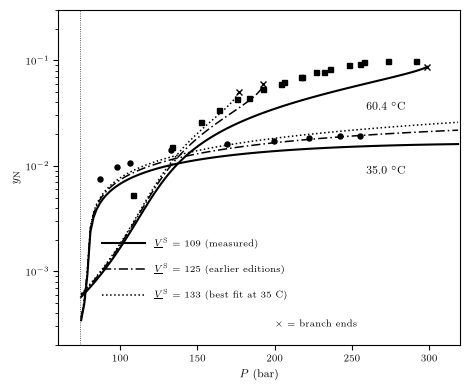

In [10]:
# --- The family of curves, both isotherms on one set of axes ------------------
#   line style -> V^S          (the variable under test)
#   marker     -> temperature  (filled circles 35.0 C, filled squares 60.4 C, as the
#                               printed caption declares)
# The two isotherms cross near 135 bar. That is real -- at low pressure the 35 C fluid is far
# denser, being only 4 C above the CO2 critical temperature -- so it is left visible.
# The SAME 2-bar grid reach() walks, so the x marks and the branch ends reported in the
# table above agree exactly. On a coarser grid they differed by one data point, which is
# the sort of disagreement a reader has no way to resolve. Memoization makes it free.
P_FAM = np.arange(PC_CO2 + 1.0, 320.0, 2.0)

fam = {}
for TC in (35.0, 60.4):
    for V, _, _ in V_SHOW:
        P_ok, Y_ok = [], []
        for P in P_FAM:
            y = y_of(TC, P, V)
            if y is None:
                break
            P_ok.append(P); Y_ok.append(y)
        fam[(TC, V)] = (np.array(P_ok), np.array(Y_ok))

fig3, ax3 = plt.subplots(figsize=(4.8, 4.0))
ax3.set_yscale("log")
for TC, marker in ((35.0, "o"), (60.4, "s")):
    for V, kw, _ in V_SHOW:
        P_ok, Y_ok = fam[(TC, V)]
        ax3.plot(P_ok, Y_ok, color="k", **kw)
        if len(P_ok) and P_ok[-1] < P_FAM[-1] - 2:
            ax3.plot(P_ok[-1], Y_ok[-1], "x", color="k", ms=4.5, mew=1.0)
    Pm, Ym = zip(*MEASURED[TC])
    ax3.plot(Pm, Ym, marker, color="k", ms=3.6, mfc="k", ls="none")
ax3.axvline(PC_CO2, color="k", lw=0.5, dashes=(1.2, 2.0))
ax3.set_xlim(60, 320); ax3.set_ylim(2e-4, 0.3)
ax3.set_xlabel(r"$P$ (bar)", fontsize=8)
ax3.set_ylabel(r"$y_{\rm N}$", fontsize=8)
ax3.tick_params(labelsize=7)
ax3.text(272, 3.4e-2, r"60.4 $^\circ$C", fontsize=8, ha="center")
ax3.text(272, 8.4e-3, r"35.0 $^\circ$C", fontsize=8, ha="center")
for n, (V, kw, lab) in enumerate(V_SHOW):
    yk = 6.0e-4 * (1.75 ** (len(V_SHOW) - 1 - n))
    ax3.plot([88, 116], [yk, yk], color="k", **kw)
    ax3.text(122, yk, r"$\underline{V}^{\rm S}$ = " + lab, fontsize=6.5, va="center")
ax3.text(200, 3.0e-4, r"$\times$ = branch ends", fontsize=6.5, ha="left")
plt.tight_layout()

print("  Branch ends on the 60.4 C isotherm (the x marks)")
for V, _, lab in V_SHOW:
    P_ok, _ = fam[(60.4, V)]
    n_in = sum(1 for P, _ in MEASURED[60.4] if P <= P_ok[-1])
    print(f"    V^S = {V:6.2f}: ends at {P_ok[-1]:3.0f} bar, covering {n_in:2d} of"
          f" {len(MEASURED[60.4])} measured points   ({lab})")
print(f"""
  Read the crosses. As V^S rises the whole family lifts toward the data -- and the cross
  marches LEFT. The volume that comes closest to the measurements is the one that reaches the
  least of them, because the same Poynting factor that raises y also drives the two lowest
  roots of Eq. 12.1-17 together until they annihilate.

  Below about 130 bar all six curves coincide: V^S barely matters until the Poynting factor
  has some pressure to work with.""")


  How the ratio VARIES with pressure -- the diagnostic, not the mean
         T     V^S   n  at low P  at high P    trend
      35.0  109.01   9      0.59       0.79     1.36x
      35.0  125.00   9      0.63       1.01     1.59x
      35.0  133.00   9      0.66       1.15     1.75x
      60.4  109.01  19      0.50       0.81     1.62x
      60.4  125.00   7      0.54       1.09     2.04x
      60.4  133.00   5      0.55       1.08     1.95x

  Every series climbs with pressure, and all six start between 0.50 and 0.66. A rising ratio is
  the signature a Poynting deficit WOULD leave, which is why raising V^S helps at all and why
  133 fits 35 C best.

  But watch the SHAPE rather than the residual. At 35 C, V^S = 133 runs 0.66 at the lowest
  pressure and 1.15 at the highest: it does not flatten the ratio onto 1.0, it TILTS it
  through 1.0 -- overshooting at the top while still 34 % low at the bottom. And the tilt
  gets STEEPER, not flatter: 1.36x at 109 against 1.75x at 133.

  A pa

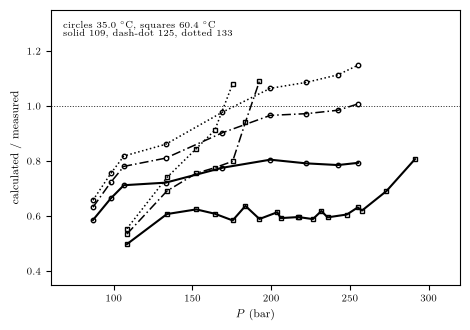

In [11]:
# --- The same comparison as a ratio, which is where the shape is legible ------
# On log axes spanning three decades a 25 % vertical shift is nearly invisible, so the figure
# above understates how far apart the curves are. calc/measured puts it on one linear axis:
# 1.0 is agreement, and a series simply stops where its branch does.
def ratio_series(TC, V):
    out = [(P, y_of(TC, P, V) / y) for P, y in MEASURED[TC] if y_of(TC, P, V) is not None]
    return np.array([q for q, _ in out]), np.array([r for _, r in out])

fig4, ax4 = plt.subplots(figsize=(4.8, 3.4))
for TC, marker in ((35.0, "o"), (60.4, "s")):
    for V, kw, _ in V_SHOW:
        Ps, rs = ratio_series(TC, V)
        ax4.plot(Ps, rs, color="k", marker=marker, ms=3.2, mfc="none", **kw)
ax4.axhline(1.0, color="k", lw=0.6, dashes=(1.2, 2.0))
ax4.set_xlim(60, 320); ax4.set_ylim(0.35, 1.35)
ax4.set_xlabel(r"$P$ (bar)", fontsize=8)
ax4.set_ylabel("calculated / measured", fontsize=8)
ax4.tick_params(labelsize=7)
ax4.annotate("circles 35.0 $^\\circ$C, squares 60.4 $^\\circ$C\nsolid 109, dash-dot 125, dotted 133",
             xy=(0.03, 0.96), xycoords="axes fraction", fontsize=6.5, va="top")
plt.tight_layout()

print("  How the ratio VARIES with pressure -- the diagnostic, not the mean")
print(f"    {'T':>6} {'V^S':>7} {'n':>3} {'at low P':>9} {'at high P':>10} {'trend':>8}")
for TC in (35.0, 60.4):
    for V, _, _ in V_SHOW:
        Ps, rs = ratio_series(TC, V)
        print(f"    {TC:6.1f} {V:7.2f} {len(rs):3d} {rs[0]:9.2f} {rs[-1]:10.2f}"
              f" {rs[-1]/rs[0]:8.2f}x")

_, r109 = ratio_series(35.0, 109.01)
_, r133 = ratio_series(35.0, 133.00)
print(f"""
  Every series climbs with pressure, and all six start between 0.50 and 0.66. A rising ratio is
  the signature a Poynting deficit WOULD leave, which is why raising V^S helps at all and why
  133 fits 35 C best.

  But watch the SHAPE rather than the residual. At 35 C, V^S = 133 runs {r133[0]:.2f} at the lowest
  pressure and {r133[-1]:.2f} at the highest: it does not flatten the ratio onto 1.0, it TILTS it
  through 1.0 -- overshooting at the top while still {(1-r133[0])*100:.0f} % low at the bottom. And the tilt
  gets STEEPER, not flatter: {r109[-1]/r109[0]:.2f}x at 109 against {r133[-1]/r133[0]:.2f}x at 133.

  A parameter that fixed the problem would drive that trend toward 1.00x. So no molar volume
  makes the ratio flat at 1.0: the discrepancy has the wrong pressure dependence to be a
  Poynting error alone.""")


In [12]:
# --- Is there any (V^S, k_ij) pair that both spans the isotherm and fits? -----
KS = [0.085, 0.103, 0.125]
print("  60.4 C: branch end (bar) / mean calc-over-measured (points reached, of 19)")
print(f"    {'V^S':>7} " + " ".join(f"{'k = '+format(k,'.3f'):>20}" for k in KS))
for V, _, _ in V_SHOW:
    row = []
    for k in KS:
        end = reach(60.4, V, k)
        if end is None:
            row.append(f"{'no branch':>20}"); continue
        rs = [y_of(60.4, P, V, k) / y for P, y in MEASURED[60.4]
              if P <= end and y_of(60.4, P, V, k) is not None]
        e = f"{end:.0f}" if end < 316 else ">320"
        row.append(f"{e} / {np.mean(rs):.2f} ({len(rs)}/{len(MEASURED[60.4])})".rjust(20))
    print(f"    {V:7.2f} " + " ".join(row))

print(f"""
  Nothing in the map gets the mean ratio near 1.0 while covering all nineteen points. Raising
  V^S or lowering k lifts the curve and pulls the truncation forward; lowering V^S or raising k
  extends the reach and drops the curve further below the data.

  So the gap in Figure 12.1-1 is not a parameter chosen badly. It is what a cubic equation of
  state with one pressure-independent k_ij does in a mixture approaching its upper critical end
  point, and McHugh and Paulaitis say as much themselves: thermodynamic formulations in the
  supercritical-fluid region are "only semiquantitative, at best". The figure gets the shape
  right across four decades, including the sharp rise through the CO2 critical pressure, while
  running about 40 % low at 60.4 C.

  That is the honest result, and it is worth more than a curve that agreed by carrying a molar
  volume 15 % too large. V^S = 109 cc/mol is a measured property with a citation; using 133
  because it fits would be putting a mixing-rule deficiency inside a Poynting factor, where a
  reader would have no way to find it.""")


  60.4 C: branch end (bar) / mean calc-over-measured (points reached, of 19)
        V^S            k = 0.085            k = 0.103            k = 0.125
     109.01    159 / 0.89 (3/19)   299 / 0.62 (19/19)  >320 / 0.31 (19/19)
     125.00    145 / 0.86 (2/19)    193 / 0.80 (7/19)  >320 / 0.40 (19/19)
     133.00    141 / 0.94 (2/19)    177 / 0.83 (5/19)   287 / 0.46 (18/19)

  Nothing in the map gets the mean ratio near 1.0 while covering all nineteen points. Raising
  V^S or lowering k lifts the curve and pulls the truncation forward; lowering V^S or raising k
  extends the reach and drops the curve further below the data.

  So the gap in Figure 12.1-1 is not a parameter chosen badly. It is what a cubic equation of
  state with one pressure-independent k_ij does in a mixture approaching its upper critical end
  point, and McHugh and Paulaitis say as much themselves: thermodynamic formulations in the
  supercritical-fluid region are "only semiquantitative, at best". The figure gets th

## Your turn

1. Illustration 12.1-5's solubility falls to a minimum near 30 bar and then rises. Derive the
   pressure at the minimum from $y \propto \exp[(a+c)P]/P$, with $a = \underline{V}^{\rm S}/RT$
   and $c$ the virial slope, and compare with the table. Then say what happens to that minimum
   as temperature rises.
2. Rerun Illustration 12.1-5 with the pressure-explicit fugacity coefficient,
   $\ln\bar\phi_i = (2\sum_j y_jB_{ij} - B_{\rm mix})P/RT$, instead of the volume-explicit
   form. The two agree at 1 bar and differ by a factor of about 1.9 in $\bar\phi$ at 60 bar.
   Which is the correct truncation of the virial series, and why does it matter more here than
   in an ordinary vapor-phase calculation?
3. The parameter study fits $\underline{V}^{\rm S}$ to the 35 °C data and gets 133 cm$^3$/mol
   against a measured 109. Work out what fractional error in the Poynting factor that
   represents at 250 bar, and confirm that it is the same size as the model's shortfall there.
   What does that tell you about *where* the deficiency actually lives?
4. Above its branch end the low-solubility root of Eq. 12.1-17 does not exist. Plot the residual
   $y\bar\phi(y)P - f^{\rm S}$ against $y$ at 180, 190 and 200 bar for
   $\underline{V}^{\rm S} = 125$ and watch the two lowest roots merge. What is the model
   claiming has happened to the fluid, and is that claim physically right at 60.4 °C?
5. Refit $k_{ij}$ separately at 35.0 and 60.4 °C against the measurements, holding
   $\underline{V}^{\rm S}$ at 109. Report both values, and say whether a single
   temperature-independent $k_{ij}$ can serve both isotherms.
6. Comment 3 of Illustration 12.1-6 quotes a solubility of 0.098 at 291.3 bar and 60.4 °C. Find
   that point in McHugh and Paulaitis's table, then ask the model for it. The two answers differ
   by about 20 %: is the sentence still safe to print, and why?
7. Enhancement factors of $10^9$ are reported for other mixtures at cryogenic conditions, per
   Comment 2. Which of the two factors in $E$ -- the Poynting factor or $1/\bar\phi$ -- can
   reach that size, and what does that imply about the solute?
